# Cálculo de medidas

De forma similar a como trabaja numpy, así que hay operaciones que pueden ser realizadas de forma similar con xarray, y las que no, igualmente pueden ser utilizadas sobre las matrices numpy dentro del objeto ``xarray,DataArray``.

Primero importamos la librería xarray y matplotlib

In [1]:
import xarray
import matplotlib.pyplot as plt

/home/peter/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Ejecutamos el siguiente comnado para que los gráficos se muestren fijadas debajo de las celdas

In [2]:
%matplotlib inline

Cargamos los mismos datos con los que estabamos trabajando, dentro de una variable ``ds``, y extraemos las variable ``ne``, que es el ``DataArray`` de la densidad de electrones

In [3]:
ds = xarray.open_dataset('jro20250516_132000.nc')
ne = ds.ne

In [4]:
ne

<xarray.DataArray 'ne' (timestamps: 154, gdalt: 43)> Size: 53kB
[6622 values with dtype=float64]
Coordinates:
  * timestamps  (timestamps) float64 1kB 1.747e+09 1.747e+09 ... 1.747e+09
  * gdalt       (gdalt) float64 344B 180.0 195.0 210.0 ... 780.0 795.0 810.0
Attributes:
    units:        m-3
    description:  Electron density (Ne)

Podemos hacer el cálculo tomando todos los valores de densidad de electrones sin importan el tiempo y altura, al usar el siguiente función

In [5]:
ne.mean()

<xarray.DataArray 'ne' ()> Size: 8B
array(7.96829073e+11)

Es también posible especificar la dimension a la que queremos limitar los valores. Por ejemplo, en función de la dimensión del ``tiempo``, entonces obtendremos un promedio barrido en el tiempo

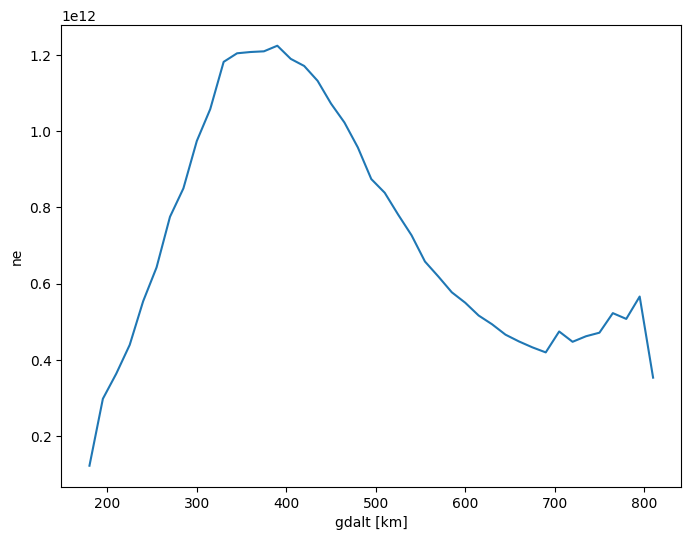

In [6]:
ne.mean(dim='timestamps').plot(size=6)

Y si queremos reducir el rango al que queremos promediar, entonces podemos especificar esto usando ``sel`` y encadenando los operadores

In [7]:
ne_clip = ne.sel(timestamps = slice(1.747411e+09,1.747452e+09)).mean(dim='timestamps')
ne_clip

<xarray.DataArray 'ne' (gdalt: 43)> Size: 344B
array([1.20959786e+11, 2.79287064e+11, 3.49039802e+11, 4.16621298e+11,
       5.12705048e+11, 6.00570413e+11, 7.22311720e+11, 8.04493047e+11,
       9.50455911e+11, 1.05205025e+12, 1.20584176e+12, 1.25789039e+12,
       1.29841595e+12, 1.33341112e+12, 1.37717436e+12, 1.34633771e+12,
       1.33509348e+12, 1.30575305e+12, 1.24459455e+12, 1.19353035e+12,
       1.13207648e+12, 1.03864316e+12, 9.96066130e+11, 9.36721949e+11,
       8.62847091e+11, 7.79335100e+11, 7.18875910e+11, 6.62137682e+11,
       6.12019339e+11, 5.70079930e+11, 5.38755006e+11, 4.89014840e+11,
       4.55164423e+11, 4.35179831e+11, 4.21157728e+11, 4.69328656e+11,
       4.46768836e+11, 4.61323327e+11, 4.70672866e+11, 5.22107804e+11,
       5.06935676e+11, 5.65725879e+11, 3.52487641e+11])
Coordinates:
  * gdalt    (gdalt) float64 344B 180.0 195.0 210.0 225.0 ... 780.0 795.0 810.0

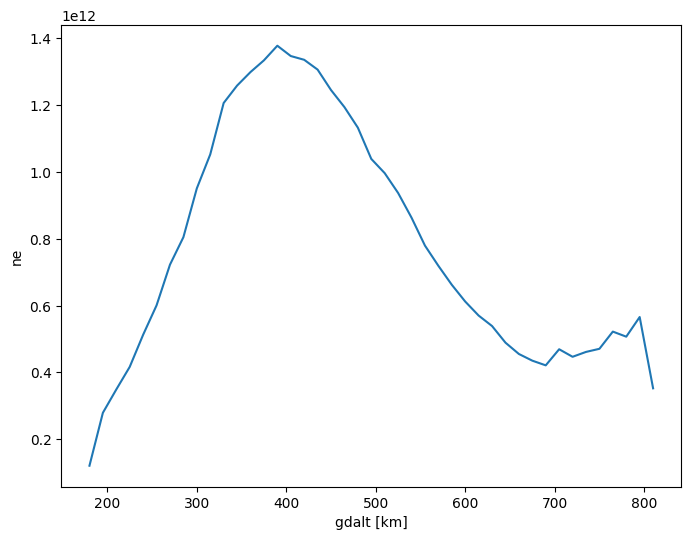

In [8]:
ne_clip.plot(size=6)

Esto nos permitirá quitar los datos que puden afectar a nuestros resultados, debido a alguna anomalia o problema sistematico. xarray compara los dos conjuntos de datos y verifica en que coordenadas se empareja, como hicimos un conjunto es un promedio temporal que no contiene coordenada temporal, entonces hace una extensión, fijando el mismo valor promedio para todos los tiempos, y hace la resta de los datos ``ne_clip`` de los datos originales en función de las coordenadas emparejadas.

In [9]:
ne_res = (ne - ne_clip)

El promedio del dataset de la resta en la que se puede apreciar una anomalía, puede ser especificada en función de otas coordendas como la altura en el argumento ``dim``. Además, se puede usar ``None`` como segundo argumento de ``slice``, que nos permite no gijar un límite superior

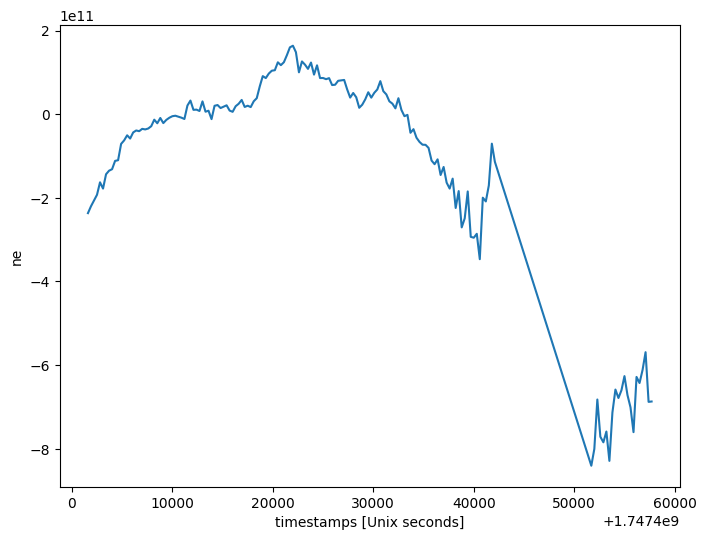

In [10]:
ne_res.isel(timestamps = slice(0,None)).mean(dim=('gdalt')).plot(size=6)